In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import json
import glob
import os
from pathlib import Path
import pandas as pd

In [23]:
def get_sum_df(path):
    data = json.load(open(path))
    rewards_data = {}
    for env_id in data.keys():
        rewards_data[env_id] = data[env_id]['rewards']
    df = pd.DataFrame(rewards_data)
    df_avg = df.applymap(lambda x: np.sum(x) if isinstance(x, list) else x)
    return df_avg

df_icrl = get_sum_df("/home/kdt3jq/ICRL_LLM/ICRL-for-LLM-Agent/ICL/sw/sciworld_data_9.json")
df_rejsample = get_sum_df("/home/kdt3jq/ICRL_LLM/ICRL-for-LLM-Agent/ICL/sw/rejsample/sciworld_data_9.json")


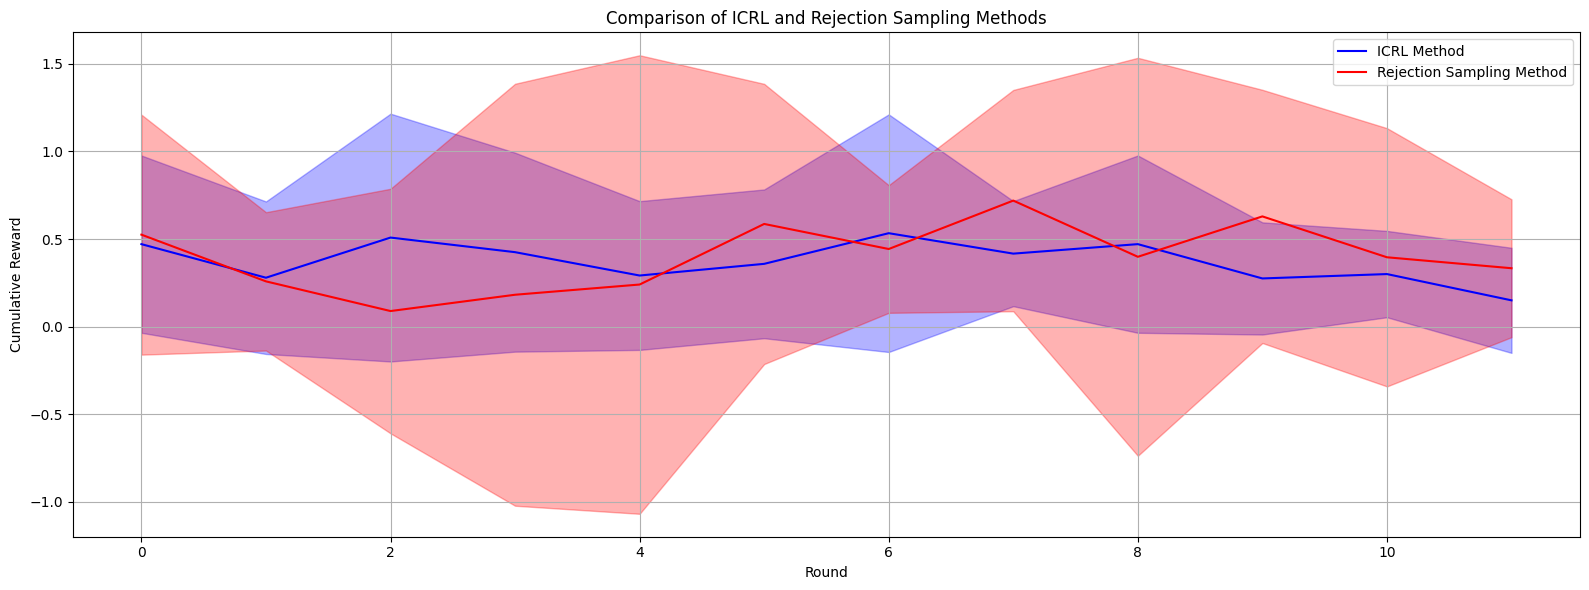

In [26]:
# Create a single figure for comparing both methods
fig, ax = plt.subplots(figsize=(16, 6))

# Plot for ICRL data
means = df_icrl.mean(axis=1)
std_devs = df_icrl.std(axis=1)
rounds = range(len(means))

ax.plot(rounds, means, 'b-', label='ICRL Method')
ax.fill_between(rounds, means - std_devs, means + std_devs, alpha=0.3, color='b')

# Plot for Rejection Sampling data
means_rej = df_rejsample.mean(axis=1)
std_devs_rej = df_rejsample.std(axis=1)
rounds_rej = range(len(means_rej))

ax.plot(rounds_rej, means_rej, 'r-', label='Rejection Sampling Method')
ax.fill_between(rounds_rej, means_rej - std_devs_rej, means_rej + std_devs_rej, alpha=0.3, color='r')

ax.set_xlabel('Round')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Comparison of ICRL and Rejection Sampling Methods')
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()